In [57]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import recall_score

In [5]:
df = pd.read_csv("data/data.csv")
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [6]:
df = df.drop(columns=['id', 'Unnamed: 32'])

In [19]:
le = LabelEncoder()

df['diagnosis'] = le.fit_transform(df['diagnosis'])

In [20]:
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [22]:
X_train, X_test, y_train, y_test = train_test_split(df.iloc[:, 1:], df.iloc[:, 0], test_size=0.3, random_state=0)

# KNearestNeighbors

### It Calculates the distance from every point and then selects K shortest distance, and whichever class has majority will be assigned to the New Point

### In KNN the features should be scaled to same level otherwise the higher value will dominate.

In [23]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [24]:
clf = KNeighborsClassifier(n_neighbors=5)

In [25]:
clf.fit(X_train_scaled, y_train)

pred = clf.predict(X_test_scaled)

recall_score(y_test, pred)

0.9047619047619048

### Main thing is the decide the value of K (n_neighbors)

In [27]:
scores = []

for i in range(1,21):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train_scaled, y_train)
    scores.append(recall_score(y_test, knn.predict(X_test_scaled)))

Matplotlib is building the font cache; this may take a moment.


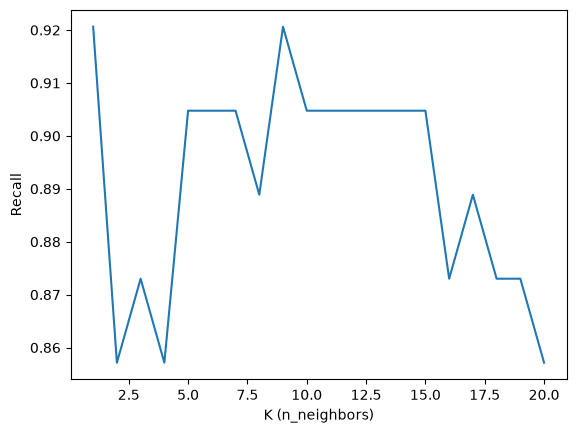

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.lineplot(x=range(1,21), y=scores)
plt.xlabel("K (n_neighbors)")
plt.ylabel("Recall")
plt.show()

The best value is came out to be 9

# Overfitting and Underfitting in KNN

<Axes: >

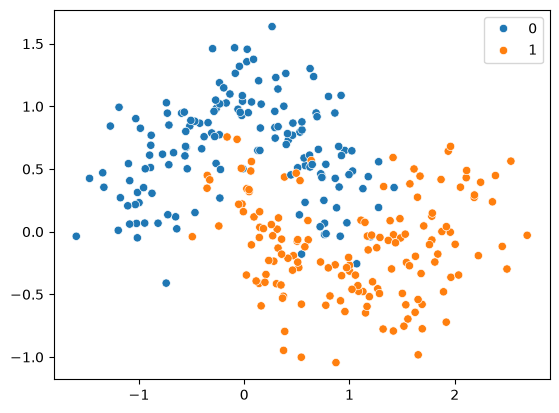

In [58]:
X, y = make_moons(
    n_samples=300,
    noise=0.25,
    random_state=42
)
sns.scatterplot(x = X[:, 0], y = X[:, 1], hue=y)

In [59]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

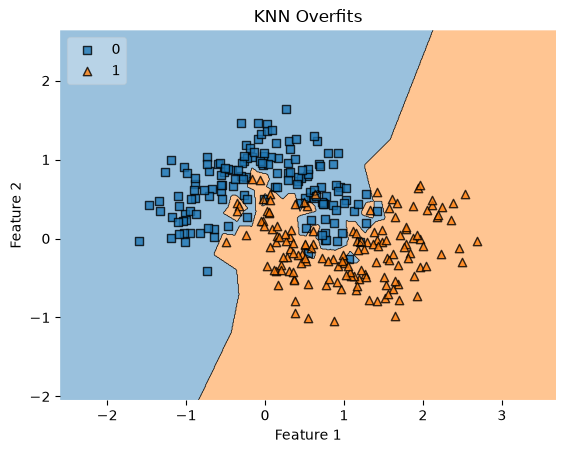

In [64]:
from mlxtend.plotting import plot_decision_regions

knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X, y)

plot_decision_regions(X, y, clf=knn, legend=2)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("KNN Overfits")
plt.show()

### OverFitting
#### On K = 1 we can see that KNN makes try to make every little regions try to fit every point, as it makes tiny tiny blue and orange region

#### If K's value is too small it Overfits

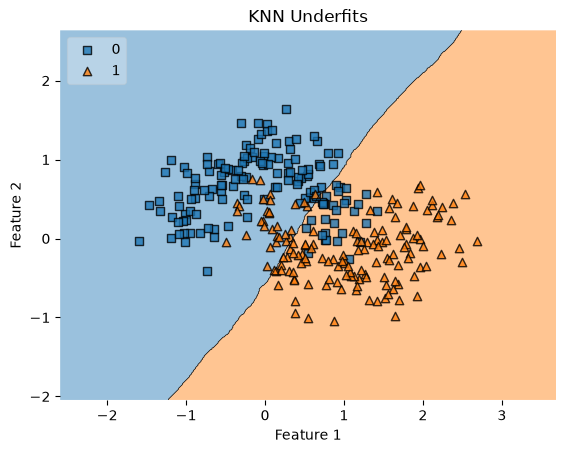

In [67]:
knn = KNeighborsClassifier(n_neighbors=200)
knn.fit(X, y)

plot_decision_regions(X, y, clf=knn, legend=2)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("KNN Underfits")
plt.show()

### Underfitting

#### As we can see if the K's value is too high it is performing bad on training data.

#### So we need to find the optimal value of K through experimentation 

# Limitation of KNN

1. Data should not be large because it take more computation.
2. High Dimensional data because of Curse of Dimensionality it is not reliable to calculate the distance in higher dimensions.
3. KNN is sensitive to Outliers.
4. Data should be on the same scale otherwise Higher value's will dominate the distance.
5. Data should not be Imbalanced.
6. KNN is not for Inference because it doesn't tell how much a feature is contributing to predict. It is good for predictions 